# Machine Learning pipeline：

---


1.   读取数据
2.   分离 X（特征）和 y（label：loan_status
3. 对 X 进行 scaling（标准化）
4. 构建并训练多个 ML 模型（至少 2 个）


*   Logistic Regression
*   Random Forest
*   也可以加 KNN、SVM（可选）
5. 比较模型性能（accuracy、precision、recall 等）
6. 写一个简单结论



In [5]:
from google.colab import files
uploaded=files.upload()

Saving loan_data.csv to loan_data.csv


In [6]:
import pandas as pd
df=pd.read_csv('loan_data.csv')

df.head()

,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,40,17.2,25579,692,5.3,895,10820,0,0,0,600,17.02,0.423,0.023,0.008,1
1,33,7.3,43087,627,3.5,169,16550,0,1,0,53300,14.10,0.384,1.237,0.412,0
2,42,1.1,20840,689,8.4,17,7852,0,0,0,2100,18.33,0.377,0.101,0.034,1
3,53,0.5,29147,692,9.8,1480,11603,0,1,0,2900,18.74,0.398,0.099,0.033,1
4,32,12.5,63657,630,7.2,209,12424,0,0,0,99600,13.92,0.195,1.565,0.522,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      50000 non-null  int64  
 1   years_employed           50000 non-null  float64
 2   annual_income            50000 non-null  int64  
 3   credit_score             50000 non-null  int64  
 4   credit_history_years     50000 non-null  float64
 5   savings_assets           50000 non-null  int64  
 6   current_debt             50000 non-null  int64  
 7   defaults_on_file         50000 non-null  int64  
 8   delinquencies_last_2yrs  50000 non-null  int64  
 9   derogatory_marks         50000 non-null  int64  
 10  loan_amount              50000 non-null  int64  
 11  interest_rate            50000 non-null  float64
 12  debt_to_income_ratio     50000 non-null  float64
 13  loan_to_income_ratio     50000 non-null  float64
 14  payment_to_income_rati

通过数据表里的其他特征（X轴）来预测loan_status是否会被允许（Y轴）

所以我们要先从数据表中删除loan_status然后把数据表变为X轴，再把loan_status单独列出来作为Y轴

In [8]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# 把数据分为测试集和训练集，训练集训练模型，用测试集测试答案（？）

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape#检查，相当于print


((40000, 15), (10000, 15))

标准化

个人理解：相当于现在的数据的分布都不平均，他们的均值和方差都不一样，画出来的分布图都不一样，但是标准化让他们全都按照***类似***正态分布图去画which is 中心为0，标准差为1的图。这样更规范更好操作。

再简单一点：统一度量衡/“把不同尺度的特征变成同一尺度，模型更好训练"

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 训练第一个模型-Logistic Regresion

---

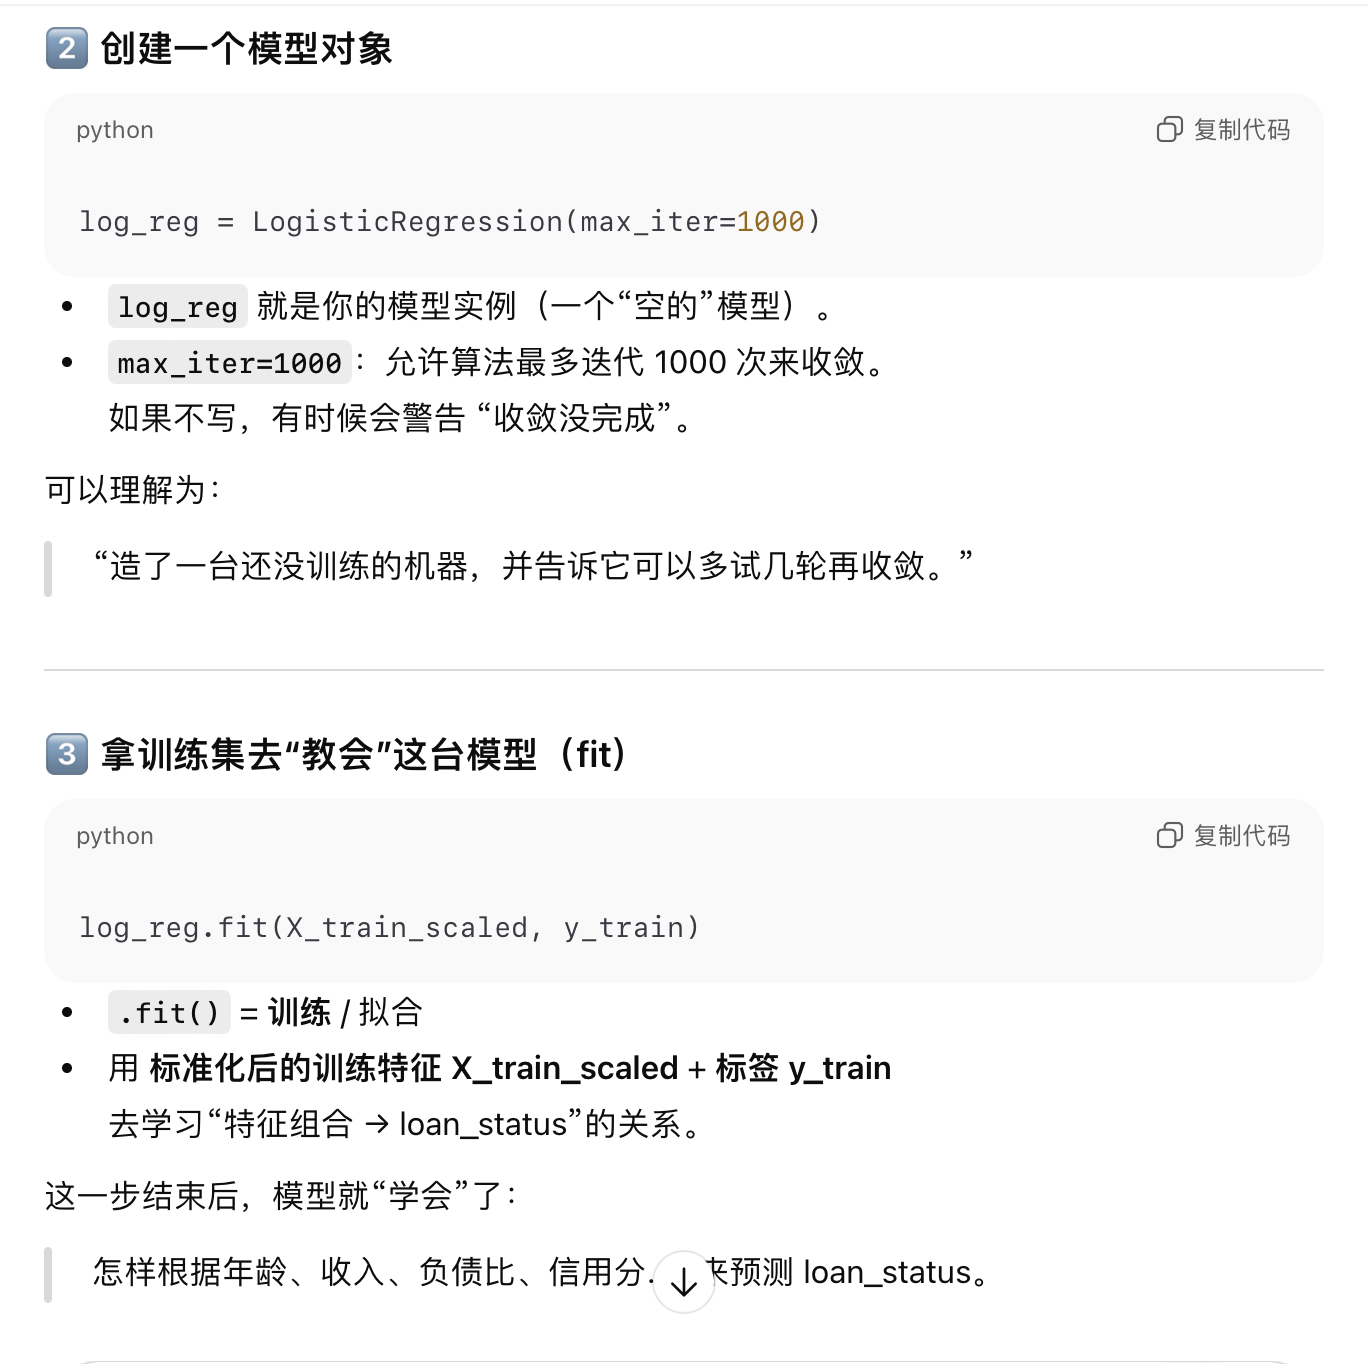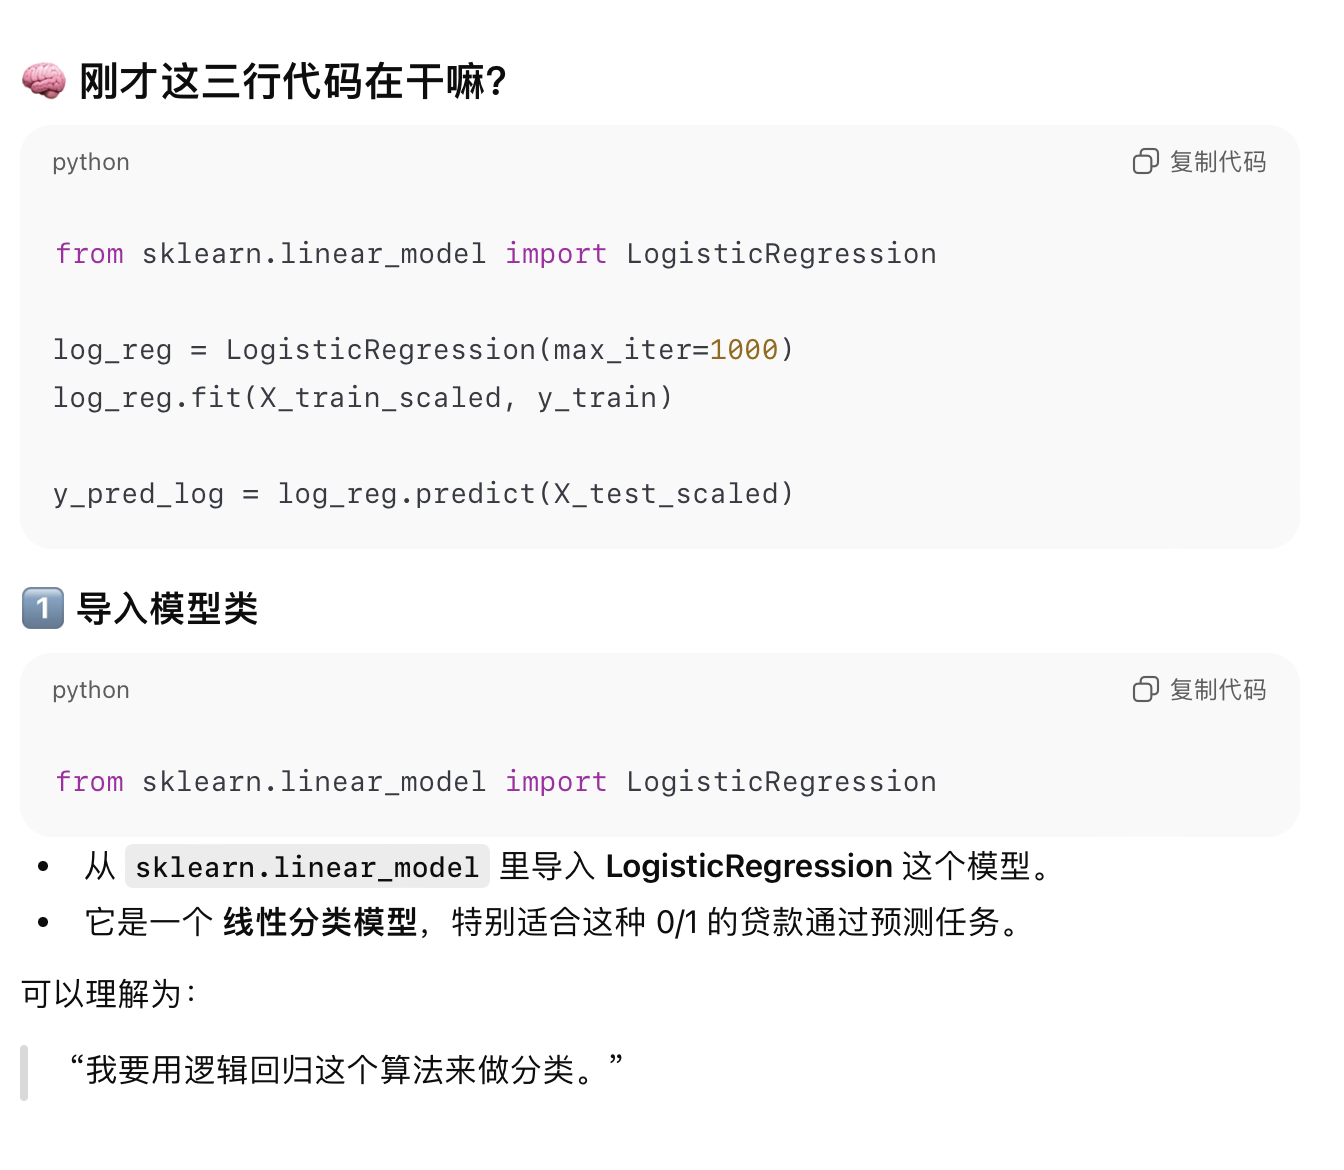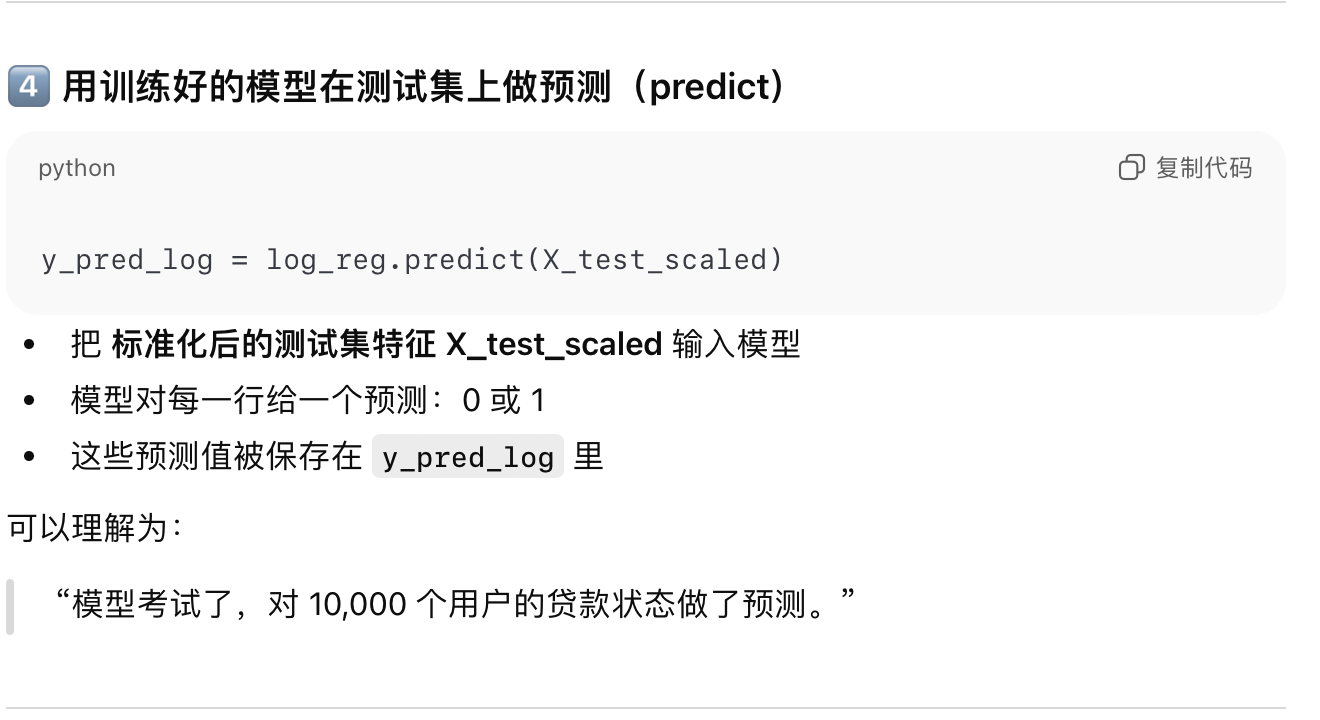

In [11]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)


# **现在开始读对比AI的准确度**

比较y_test（本来的数据） & y_pred_log（机器根据训练演算出来的数据）

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print()
print("Classification report:")
print(classification_report(y_test, y_pred_log))
print()
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_log))


Accuracy: 0.8412

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      4509
           1       0.85      0.87      0.86      5491

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000


Confusion matrix:
[[3648  861]
 [ 727 4764]]


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)


Random Forest Confusion Matrix


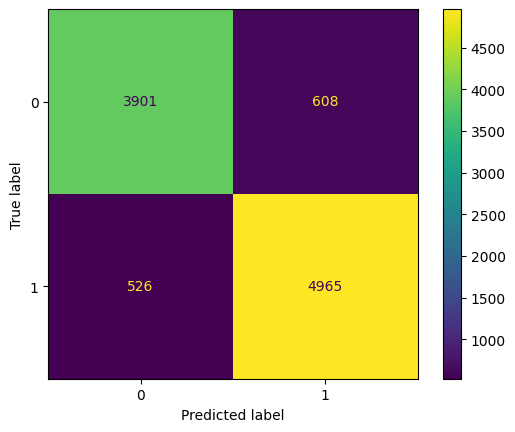

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay as CM
import matplotlib.pyplot as plt
import seaborn as sns
print('Random Forest Confusion Matrix')
predict=rf.predict(X_test_scaled)
CM.from_predictions(y_test,predict)

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy (Random Forest):", accuracy_score(y_test, y_pred_rf))
print()
print("Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))
print()
print("Confusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))


Accuracy (Random Forest): 0.8866

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      4509
           1       0.89      0.90      0.90      5491

    accuracy                           0.89     10000
   macro avg       0.89      0.88      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Confusion Matrix (Random Forest):
[[3901  608]
 [ 526 4965]]


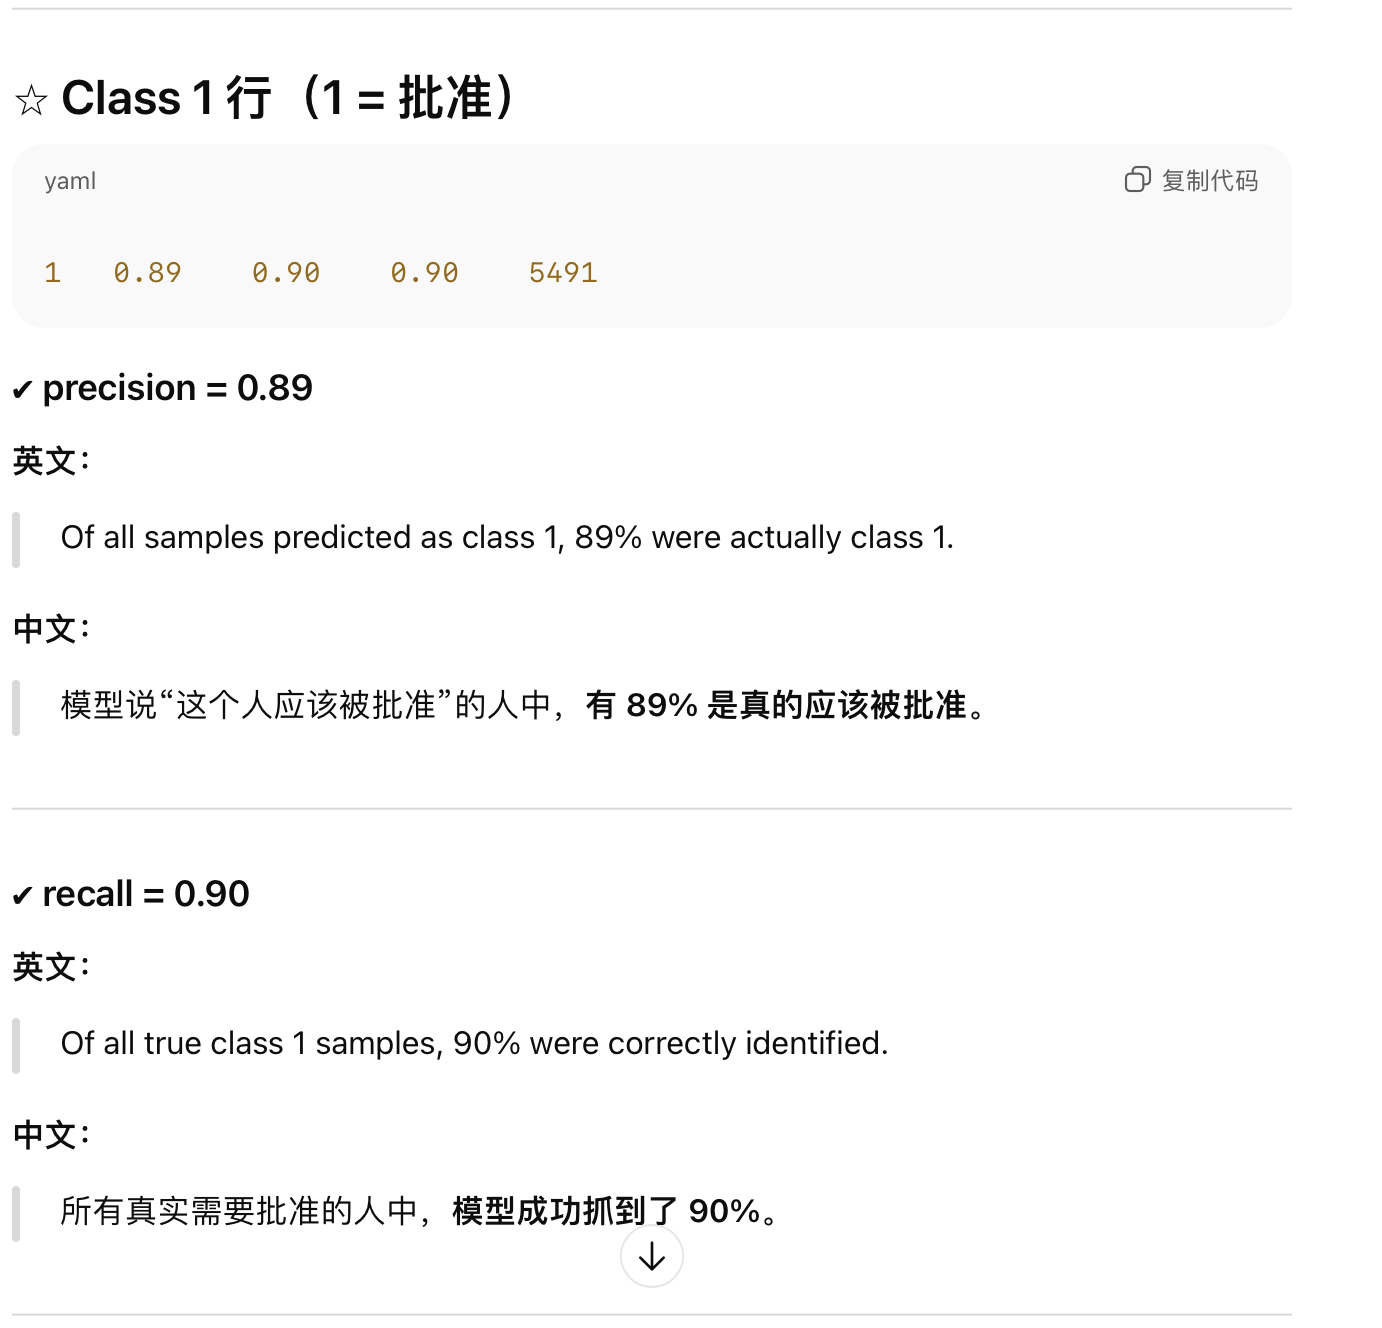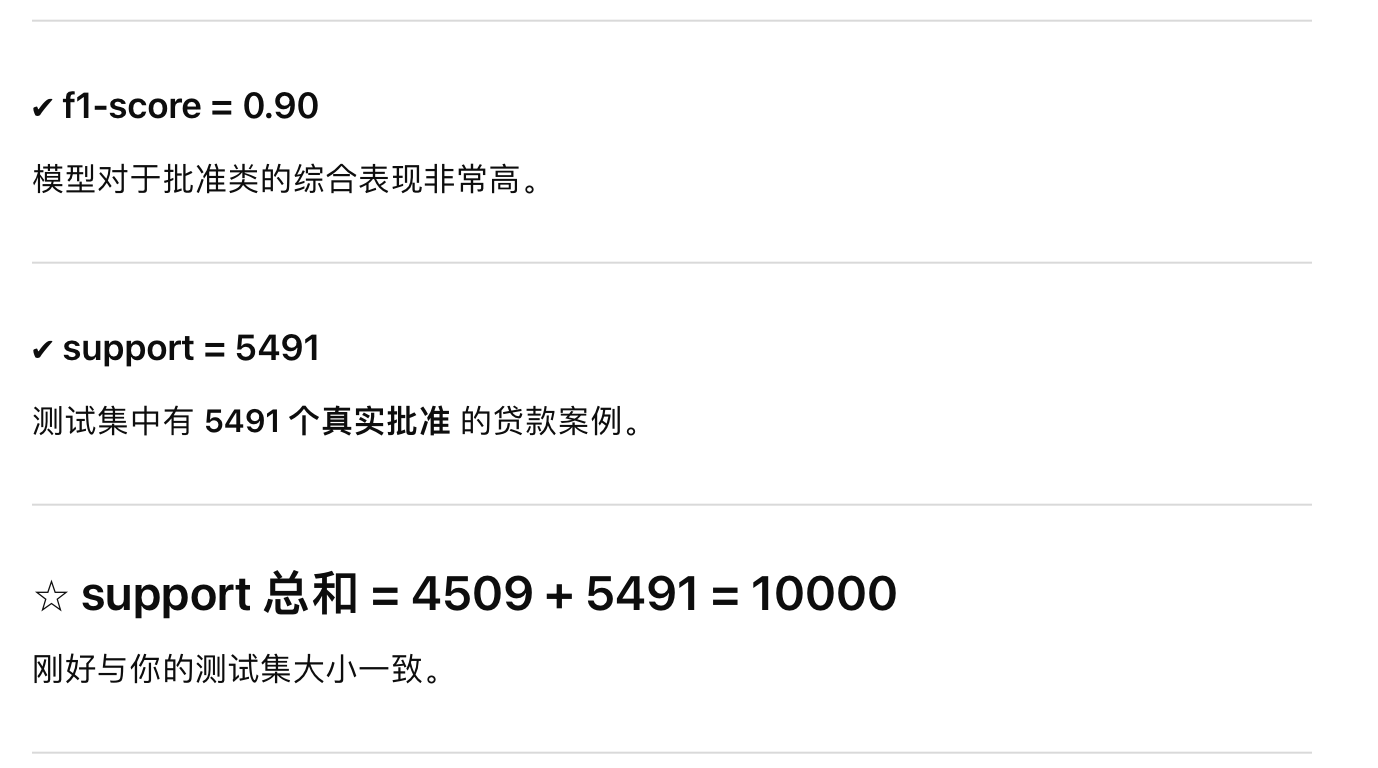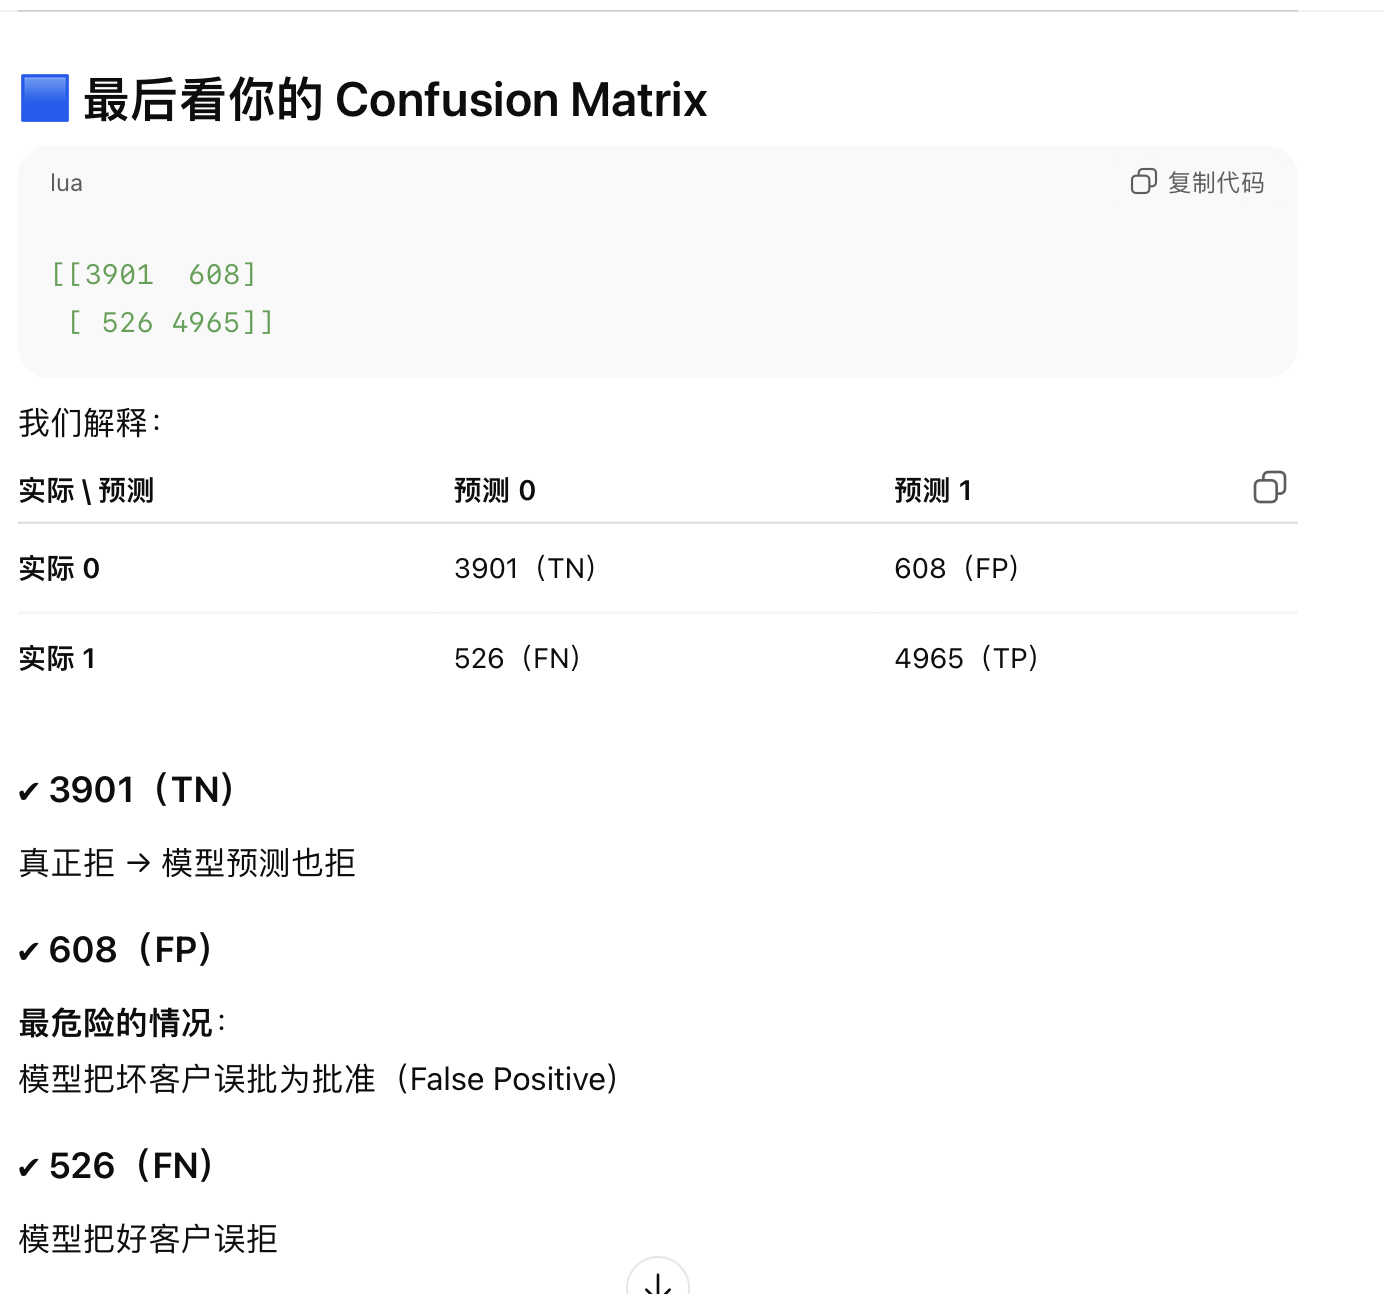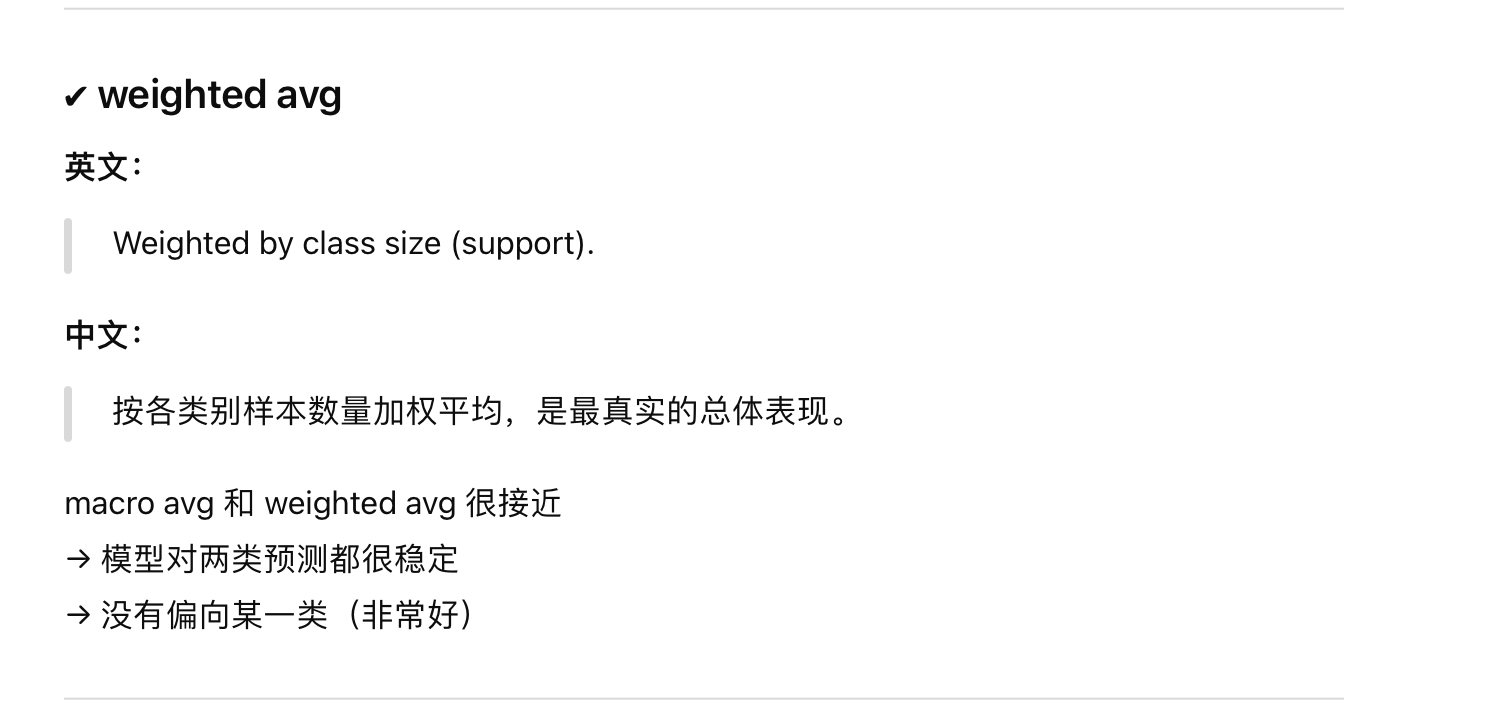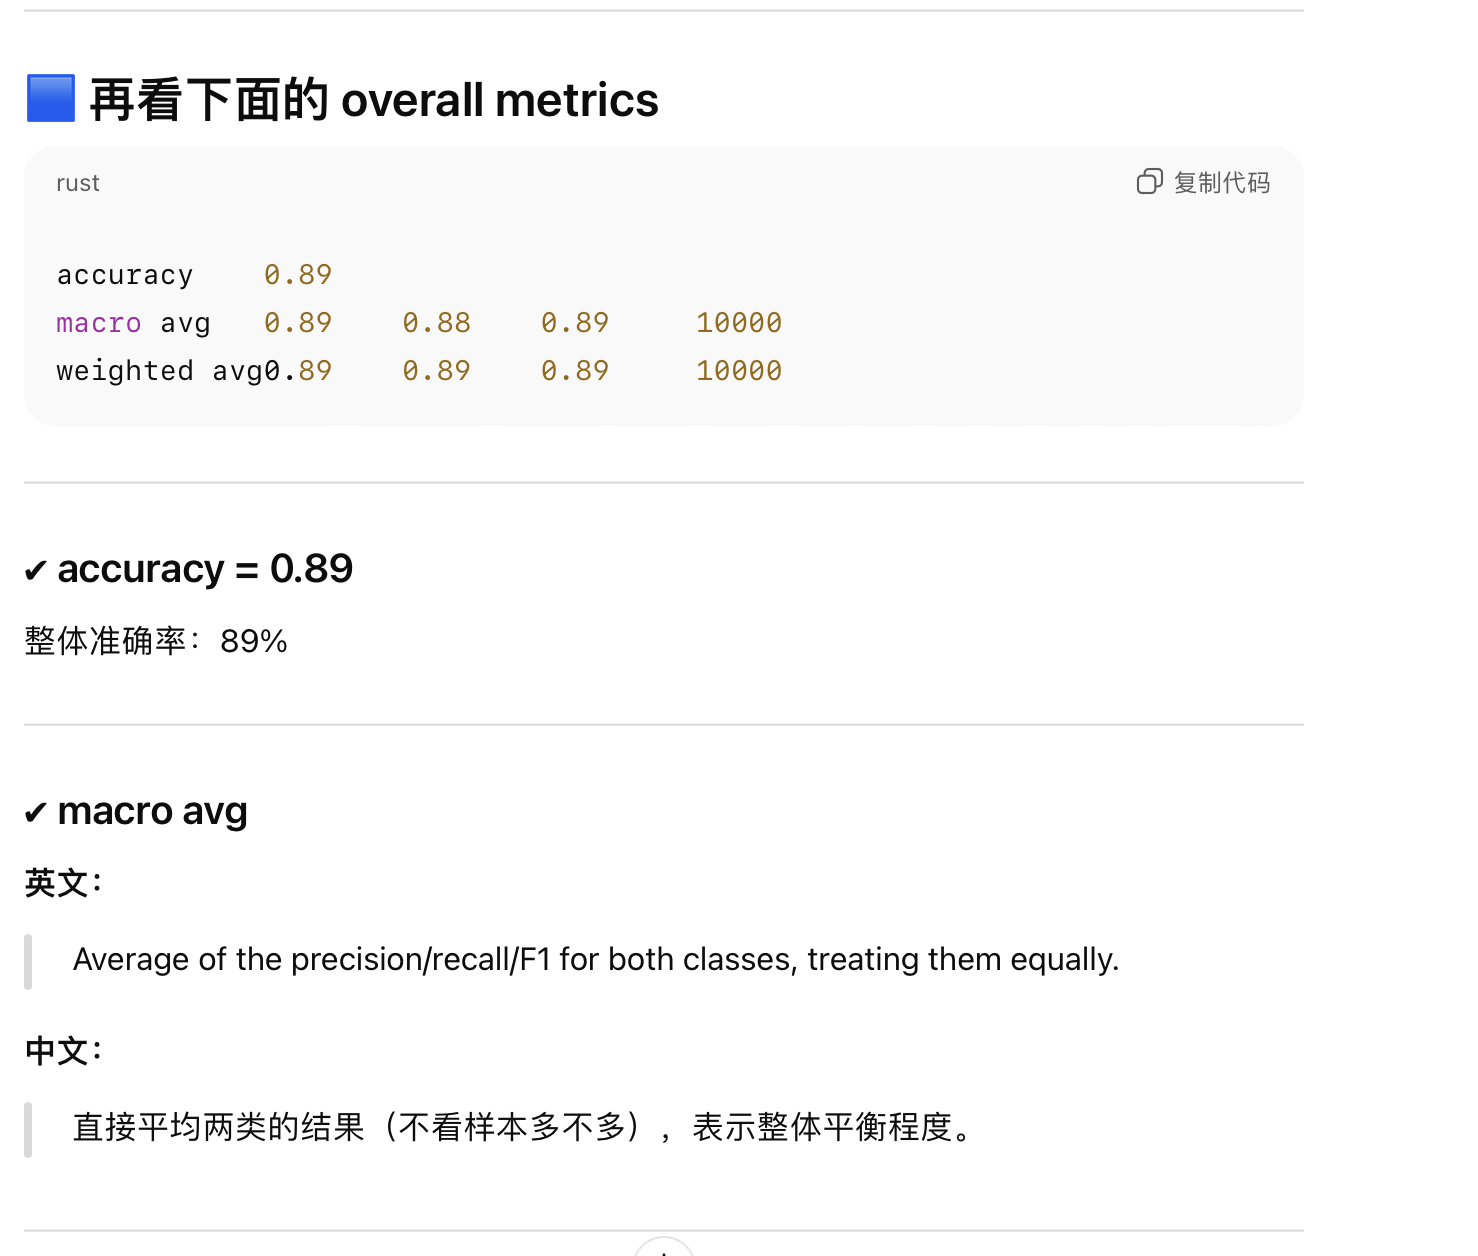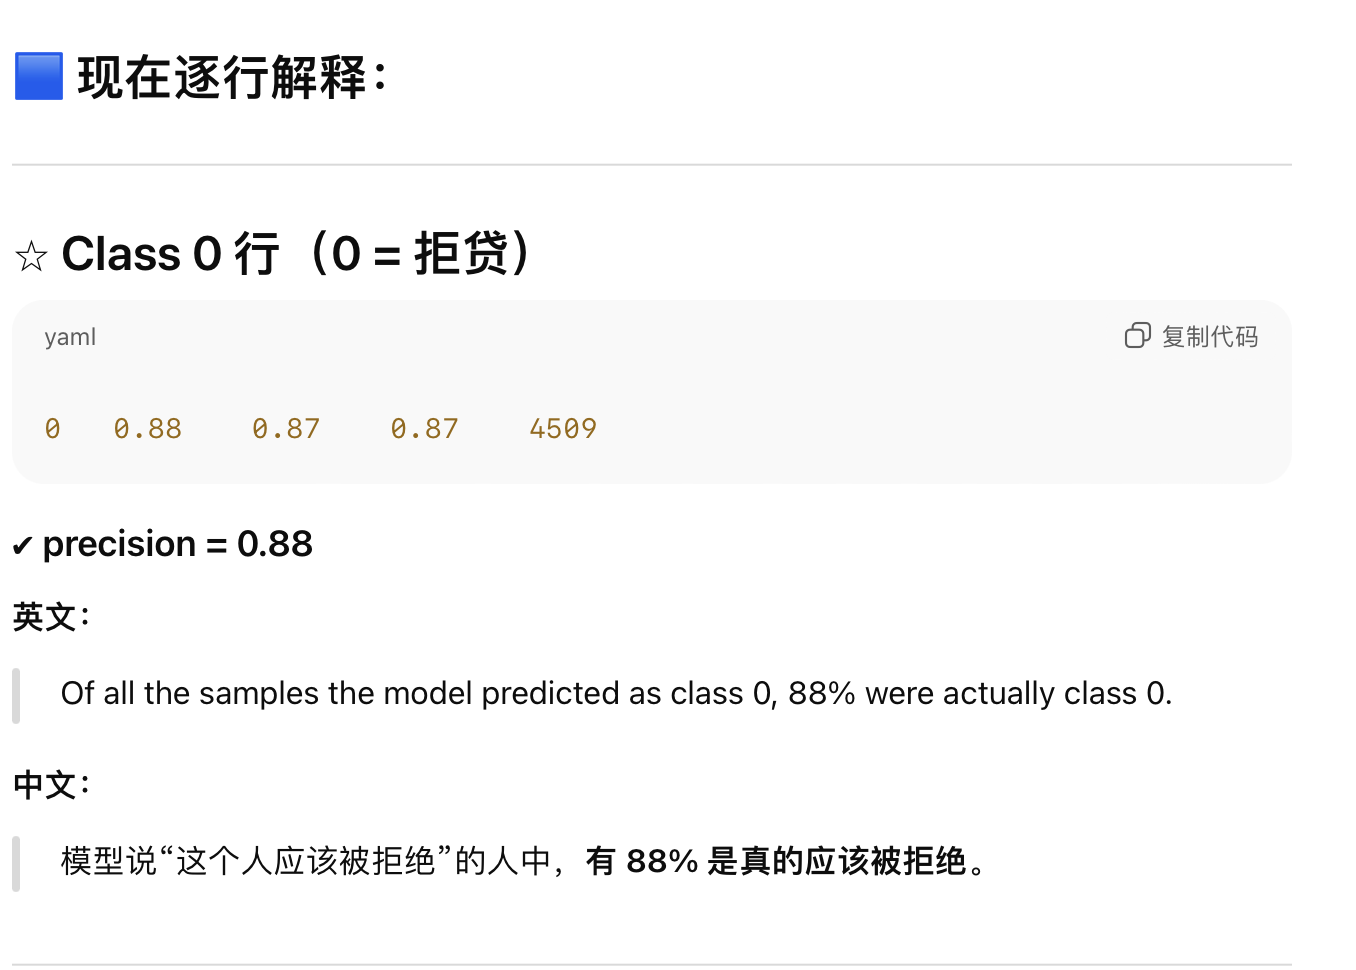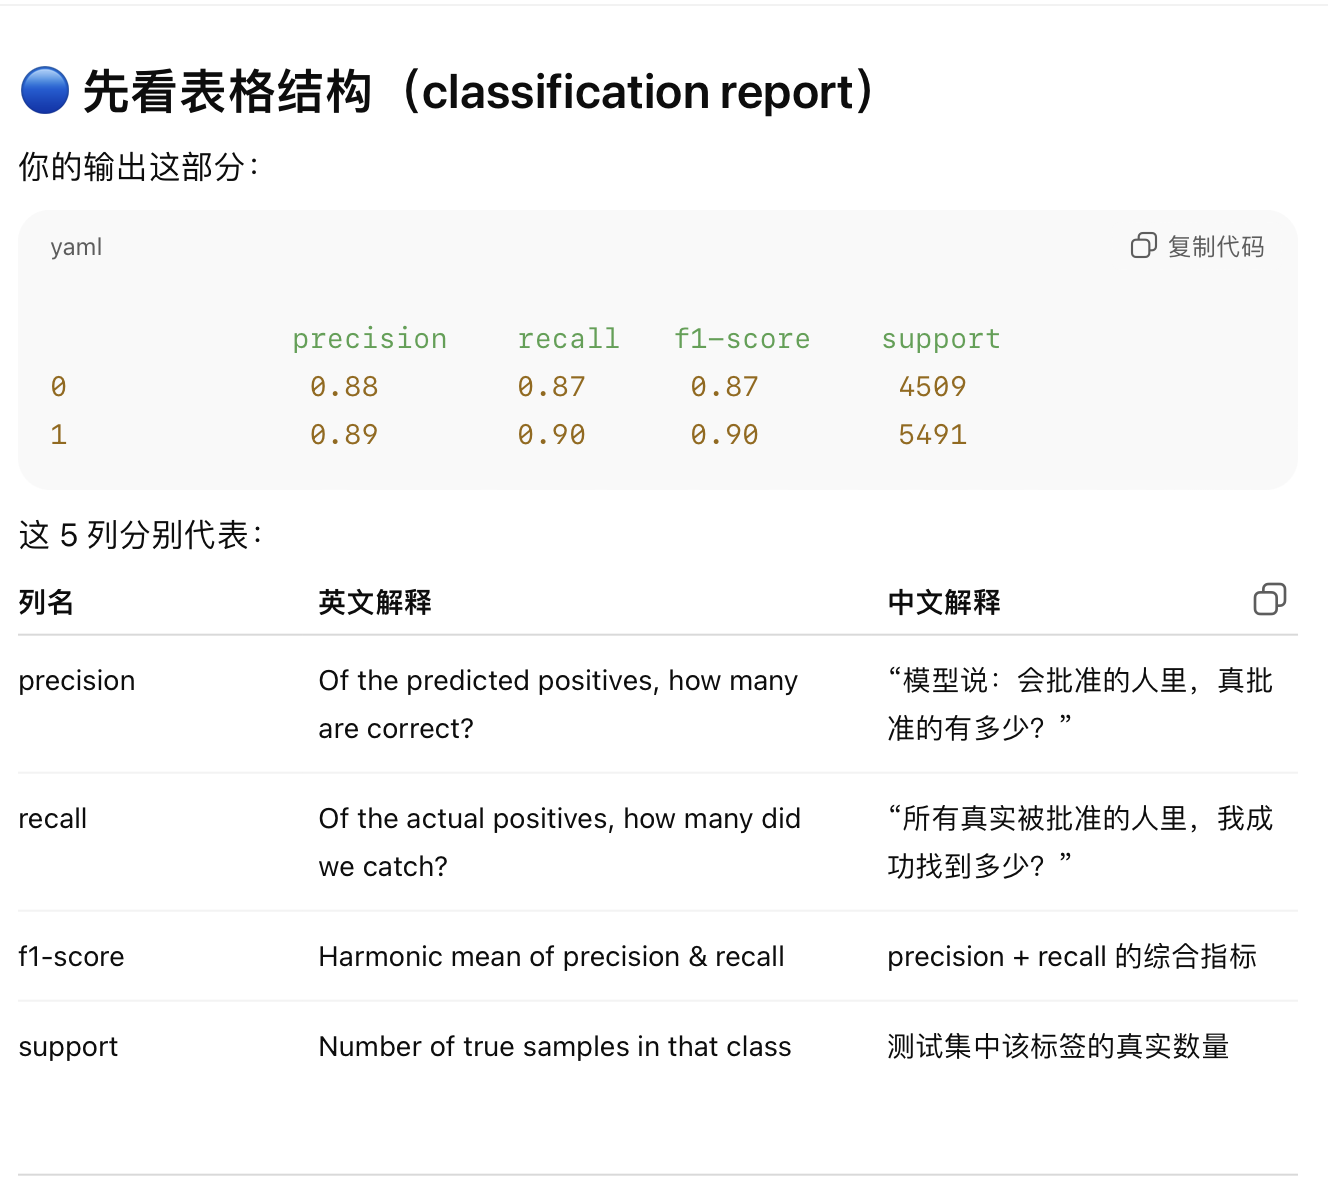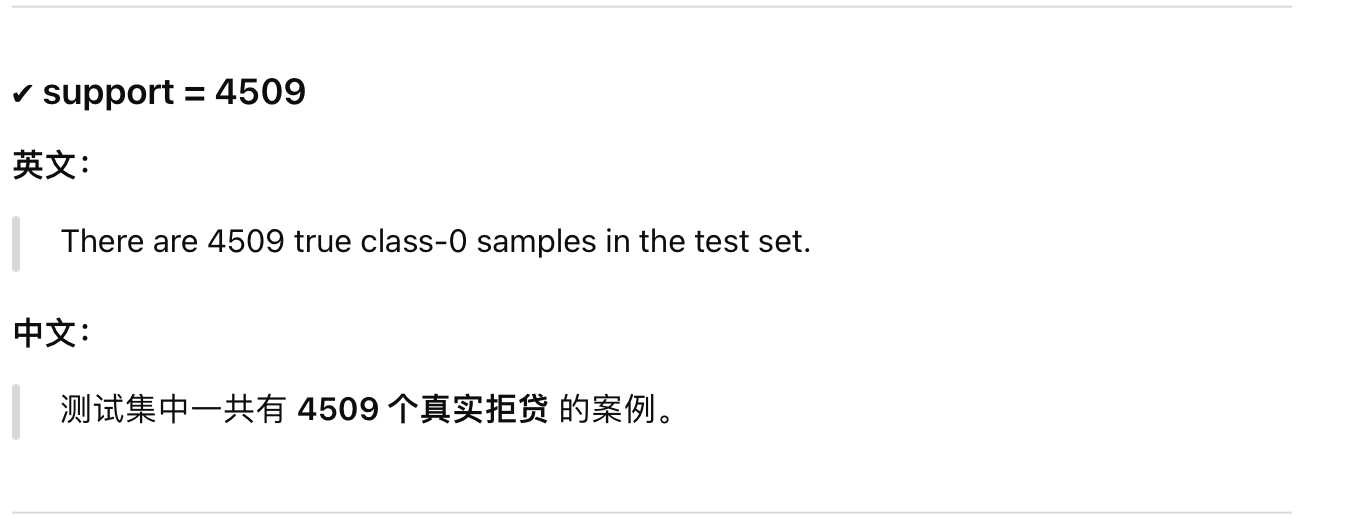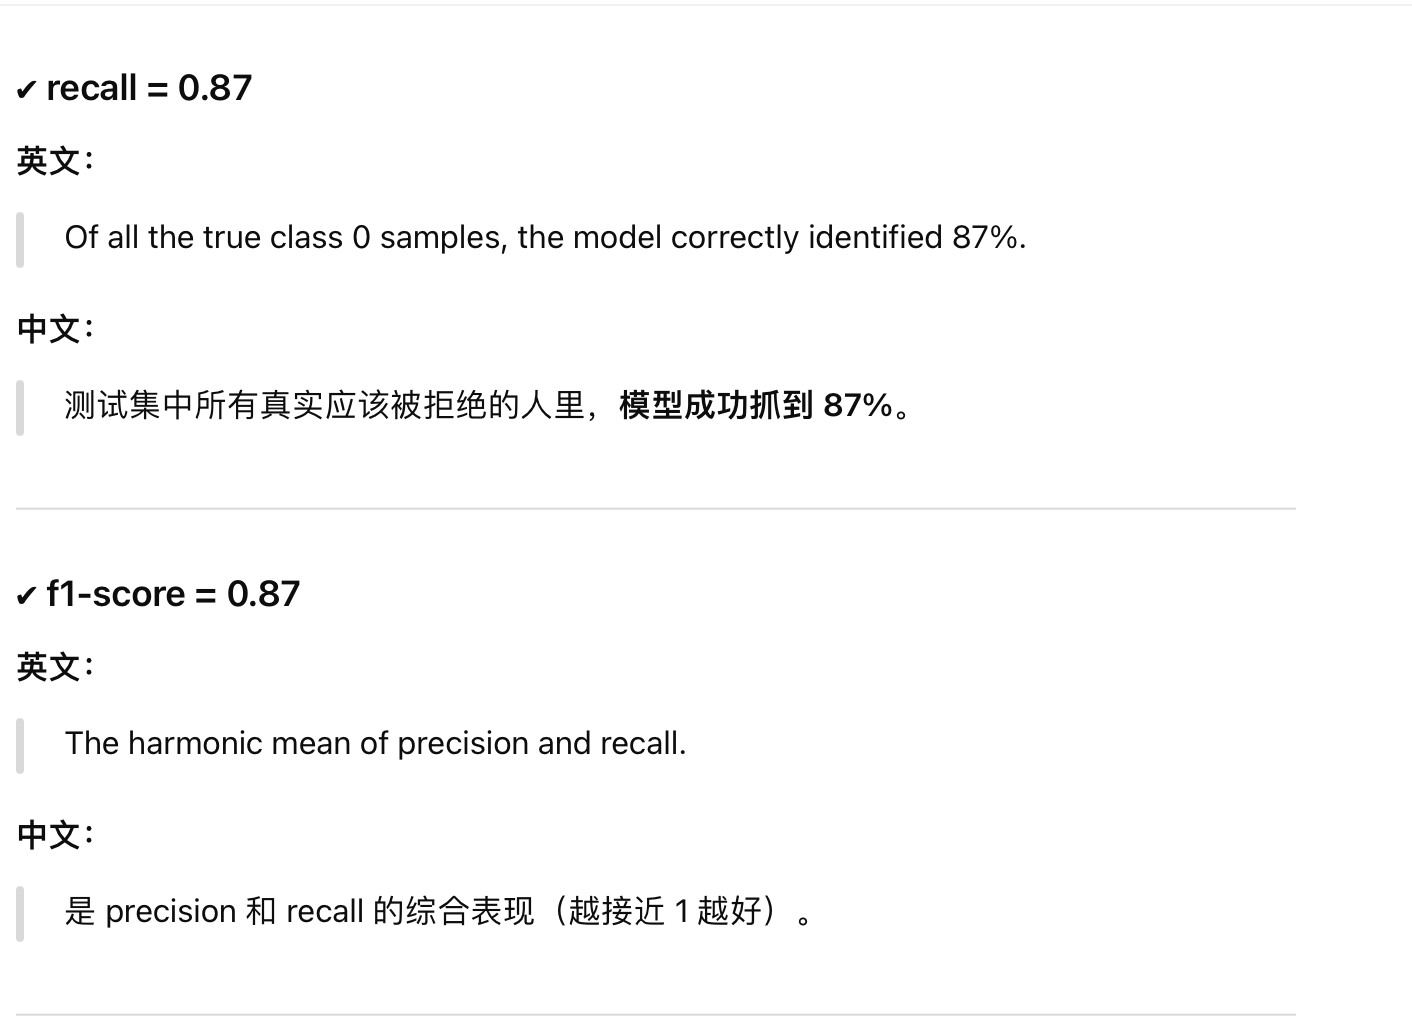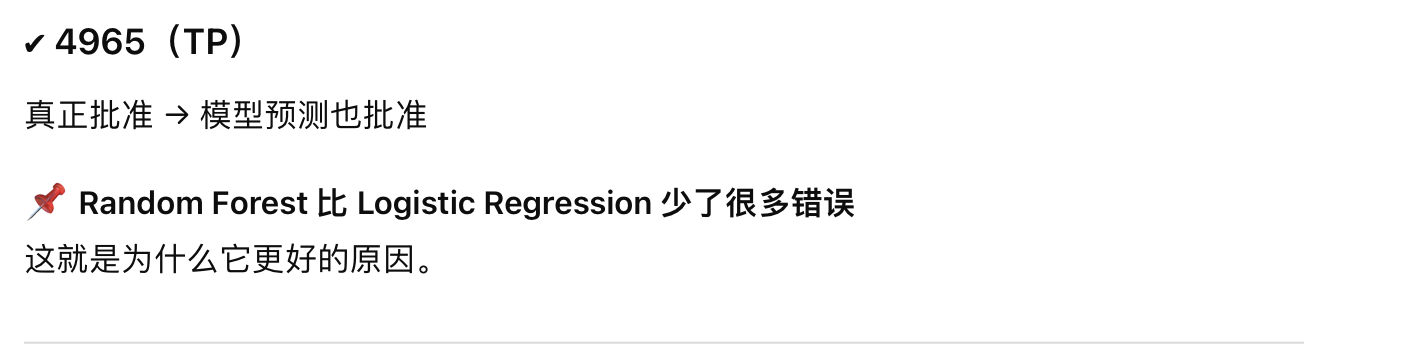